# Reinforcement Learning - Can I Graduate?

연구실, 집, 노래방을 갈 수 있는 대학원생이 있다. 스트레스와 지식을 관리해가면서 퇴학이나 번아웃 없이 졸업하자. This 'graduate student' agent can move between home, lab, and karaoke. Let's make it finish their degree without getting expelled or burned out.

https://docs.google.com/document/d/1oRslebHK2009GHblLYoQJBYeagG6hvdikvR-RiD7oxc/edit?usp=sharing

서울대학교 김준형 제작

In [1]:
import gymnasium as gym
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import imageio
from IPython.display import clear_output

from stable_baselines3 import DDPG
from stable_baselines3 import PPO
from stable_baselines3 import A2C

from callbacks.callback_not_vectorized import RewardPlotCallback
from env_gradstudent import GradStudentEnv

In [2]:
# 에이전트 초기화
device = torch.device("cpu")

env = GradStudentEnv(render_mode="human")
obs, _ = env.reset()

model = PPO("MultiInputPolicy", env, verbose=1, device=device)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


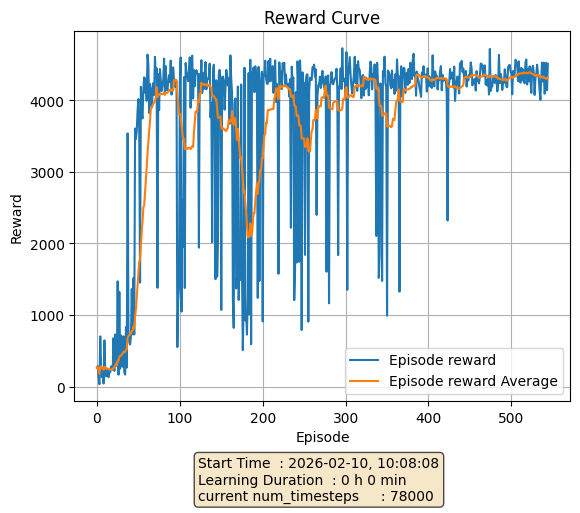

<Figure size 640x480 with 0 Axes>

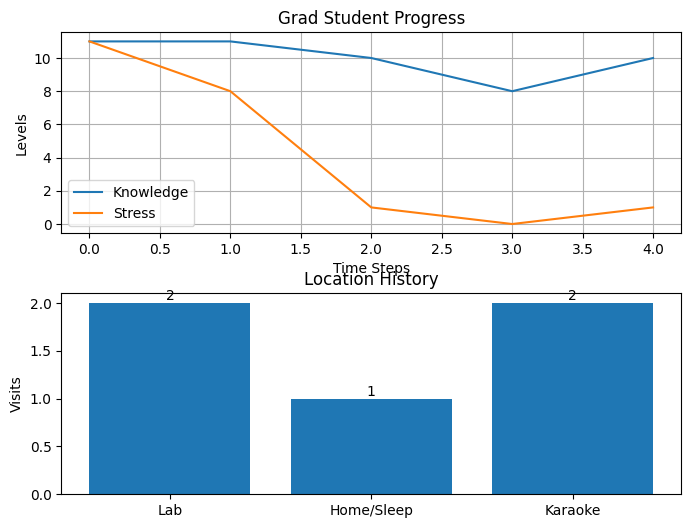

KeyboardInterrupt: 

In [3]:
# 에이전트 학습
plt.ion()  # Turn on interactive plotting
model.learn(total_timesteps=100_000_000, callback=RewardPlotCallback(plot_freq=1000))
# model.learn(total_timesteps=100_000_000, callback=CombinedCallback(plot_freq=1000, save_freq=10000))
 
plt.ioff()  # Turn off interactive mode after training
plt.show()

Reward: 2642.95, Total Reward: 4100.95


<Figure size 640x480 with 0 Axes>

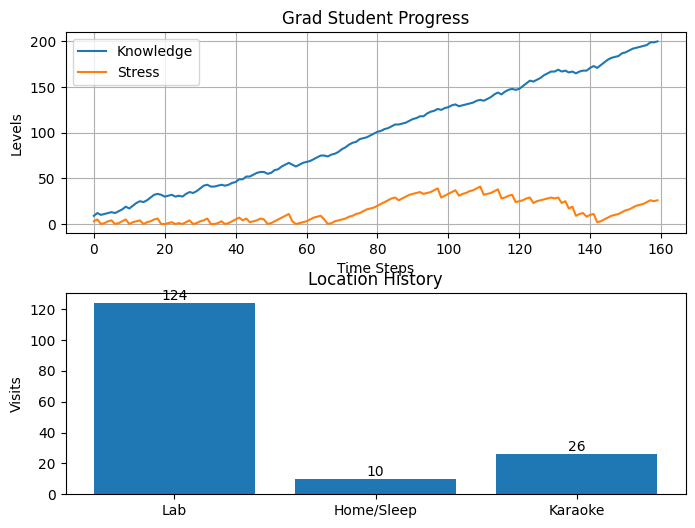

Reward: 2642.95, Total Reward: 4100.95


In [ ]:
# 학습후 결과
env = GradStudentEnv(render_mode="human")
obs, _ = env.reset()
done = False
total_reward = 0

while done == False:
    if env.render_mode == "human":
        clear_output(wait=True)
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
    print(f"Reward: {reward:.2f}, Total Reward: {total_reward:.2f}")
    env.render()
    
print(f"Reward: {reward:.2f}, Total Reward: {total_reward:.2f}")
    

## 학습 후 단계들

In [ ]:
# 모델 저장
model.save("rl_model.zip")
del model  # 모델 삭제
model = PPO.load("rl_model.zip") # 모델 불러오기


figure saved to ./frames_260210_1009/frame_0138.png



<Figure size 640x480 with 0 Axes>

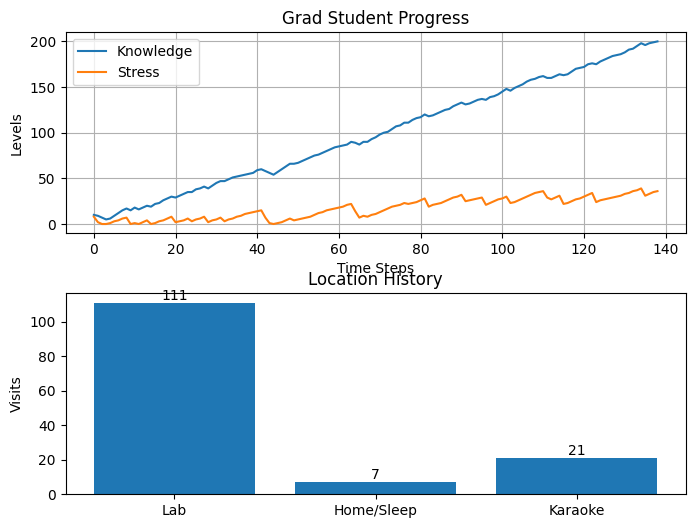

Reward: 2955.59, Total Reward: 4201.09
Reward: 2955.59, Total Reward: 4201.09


In [6]:
# 비디오로 저장 imageio 사용

env = GradStudentEnv(render_mode="human")
obs, _ = env.reset(options='SaveVideo')
done = False
total_reward = 0

while done == False:
    if env.render_mode == "human":
        clear_output(wait=True)
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
    env.render()
    print(f"Reward: {reward:.2f}, Total Reward: {total_reward:.2f}")
    # print(f"Reward: {reward}, Total Reward: {total_reward}")
    
print(f"Reward: {reward:.2f}, Total Reward: {total_reward:.2f}")

In [7]:
folder_name = "frames_260210_1009" # 해당 폴더명으로 변경할것

In [8]:
output_path = f"episode_video.mp4" #파일 이름

# Get sorted list of .png frame files
frame_files = sorted([
    os.path.join(folder_name, f)
    for f in os.listdir(folder_name)
    if f.endswith(".png") and f.startswith("frame_")
])

# Read the first image to get shape
first_image = imageio.imread(frame_files[0])
height, width = first_image.shape[:2]

# Create video writer
writer = imageio.get_writer(output_path, fps=10, codec='libx264')

# Write all frames
for fname in frame_files:
    img = imageio.imread(fname)
    writer.append_data(img)

writer.close()
print(f"Video saved to {output_path}")

/var/folders/yz/1lg4nz991_bcj__dw52cm1980000gn/T/ipykernel_23976/3718833778.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  first_image = imageio.imread(frame_files[0])
/var/folders/yz/1lg4nz991_bcj__dw52cm1980000gn/T/ipykernel_23976/3718833778.py:19: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(fname)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size

Video saved to episode_video.mp4
